# Quick start

SynForecast generates synthetic time-series panels — validated, reproducible, and in the same long format as the rest of the Nixtlaverse. This guide goes from a one-line panel to explicitly controlled generators, injected real-world patterns, and mixed datasets.

::: {.callout-tip}
## Common uses

- **Testing** a forecasting pipeline on data whose true process you know, before trusting it on real series.
- **Augmenting** a small panel so a global model has more to learn from — see [SynAugment](/synforecast/docs/capabilities/augmentation.html).
- **Pretraining** foundation models on a diverse corpus no single real dataset provides.
- **Sharing** a reproducible example without exposing proprietary data.
:::

## 1. Generate a panel in one line

`generate_series` draws from a balanced pool of generators spanning trends, seasonality, volatility clustering, counts, and more, then returns a panel you can hand straight to any Nixtla forecaster.

In [ ]:
from synforecast import generate_series

panel = generate_series(
    n_series=6,
    freq="D",
    min_length=200,
    max_length=200,
    engine="polars",
    seed=1,
)
panel.head()

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,0.705375
"""0""",2000-01-02 00:00:00,0.838695
"""0""",2000-01-03 00:00:00,0.303755
"""0""",2000-01-04 00:00:00,-0.502002
"""0""",2000-01-05 00:00:00,0.060002


::: {.callout-note}
## The Nixtla long format

Every SynForecast output uses three columns — `unique_id` (series id), `ds` (timestamp), and `y` (value) — the schema `statsforecast`, `mlforecast`, and `neuralforecast` all expect, so no adapter is needed. The default `engine="pandas"` returns a pandas frame; pass `engine="polars"` (as here) for Polars.
:::

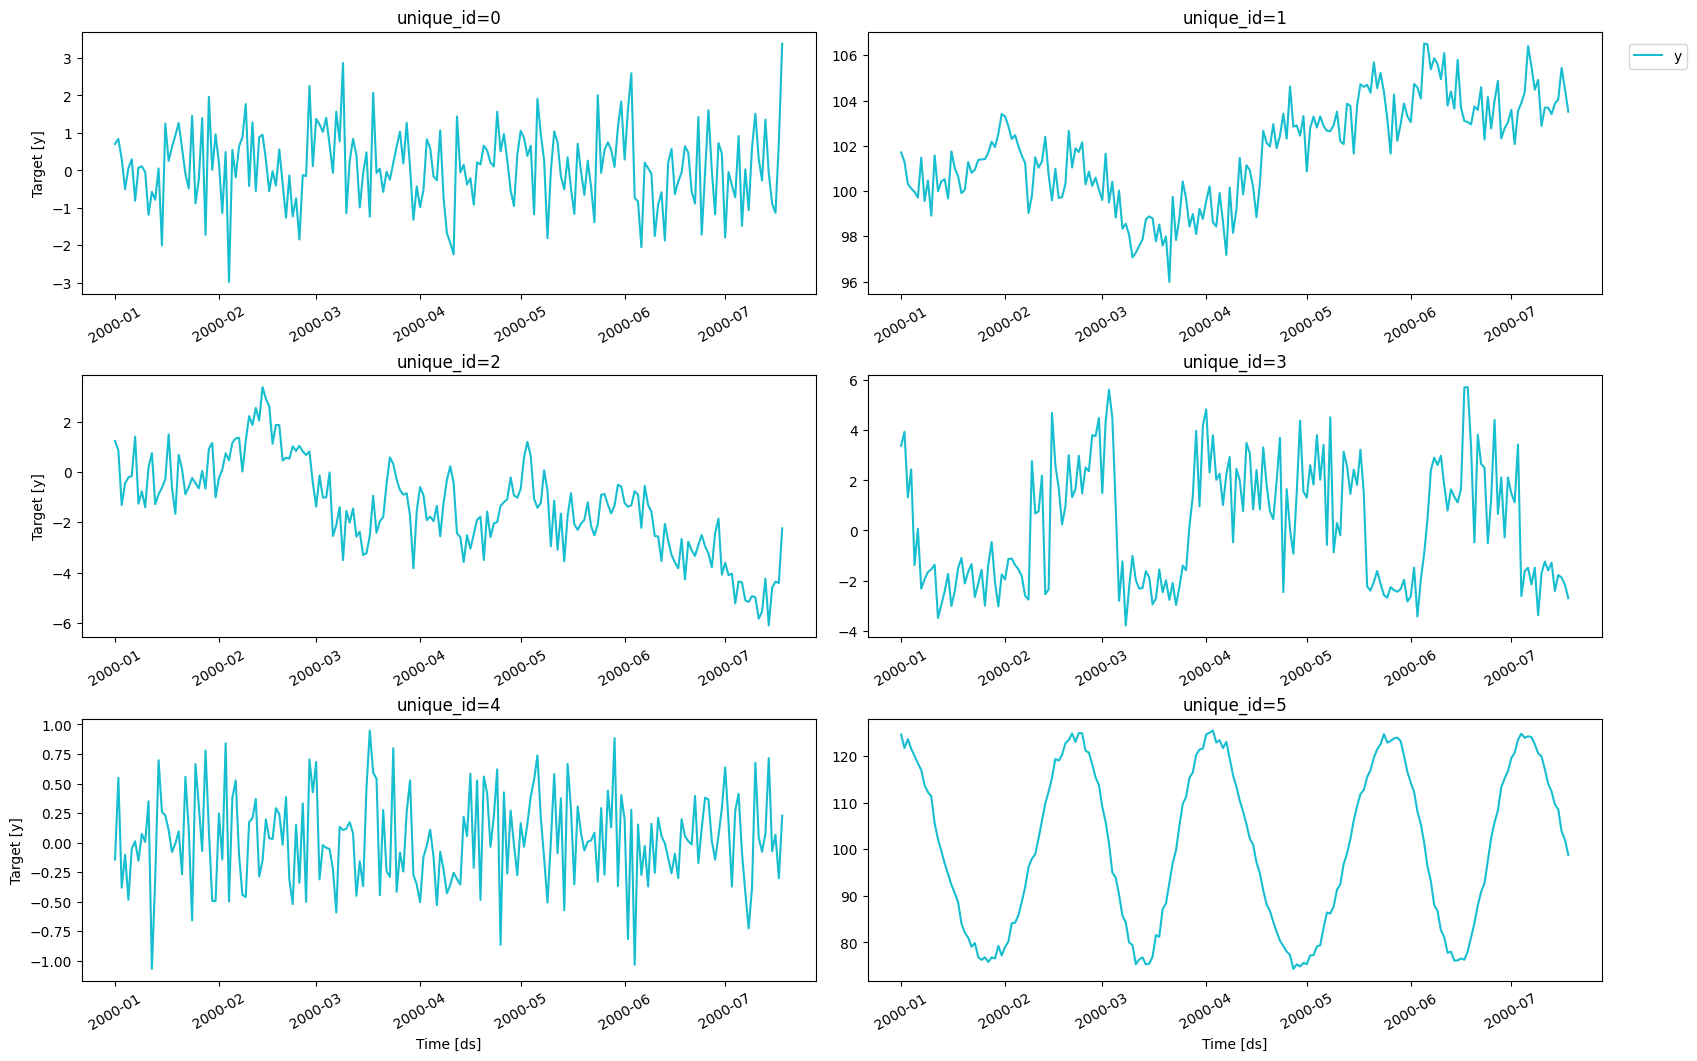

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
from utilsforecast.plotting import plot_series


def plot_panel(df, title, max_series=8):
    """Overlay a panel on one axis, for series that share a data-generating process."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for uid in df["unique_id"].unique(maintain_order=True).to_list()[:max_series]:
        series = df.filter(pl.col("unique_id") == uid)
        ax.plot(series["ds"], series["y"], linewidth=1, alpha=0.8, label=str(uid))
    ax.set(title=title, xlabel="ds", ylabel="y")
    ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    plt.show()


# These six series come from six different generators, so their scales differ by
# an order of magnitude. One panel per series keeps the small-amplitude
# processes readable; `plot_panel` above is for series that share a process.
plot_series(panel, max_ids=6, plot_random=False)


Each line is a different data-generating process. Together they cover ARIMA dynamics, exponential smoothing, long memory, regime switching, volatility clustering, and irregular cycles. That diversity is what turns the panel into a stress test for a forecaster rather than one shape repeated six times.

Don't take that on trust — pass `with_generator_col=True` to record which generator produced each series:

In [ ]:
provenance = generate_series(
    n_series=6,
    freq="D",
    min_length=200,
    max_length=200,
    engine="polars",
    seed=1,
    with_generator_col=True,
)
per_series = provenance.group_by("unique_id", "generator").len().sort("unique_id")
print(per_series)
assert per_series["generator"].n_unique() == 6, "panel should span 6 generators"

shape: (6, 3)
┌───────────┬─────────────────────────────────┬─────┐
│ unique_id ┆ generator                       ┆ len │
│ ---       ┆ ---                             ┆ --- │
│ cat       ┆ str                             ┆ u32 │
╞═══════════╪═════════════════════════════════╪═════╡
│ 0         ┆ SARIMAGenerator                 ┆ 200 │
│ 1         ┆ ETSGenerator                    ┆ 200 │
│ 2         ┆ FractionalBrownianMotionGenera… ┆ 200 │
│ 3         ┆ RegimeSwitchingGenerator        ┆ 200 │
│ 4         ┆ GARCHGenerator                  ┆ 200 │
│ 5         ┆ CyclicGenerator                 ┆ 200 │
└───────────┴─────────────────────────────────┴─────┘


## 2. Choose a generator when you need control

`generate_series` is the fast default. When you need a known process — for example, to confirm your model recovers an upward trend — instantiate a generator and set its parameters explicitly. Here, a random walk with positive drift and moderate volatility.

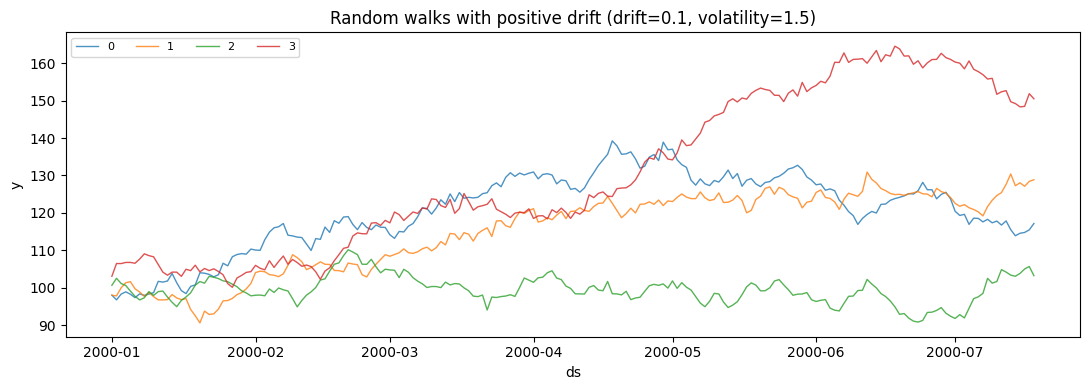

In [ ]:
from synforecast.generators import RandomWalkGenerator

rw = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    drift=0.1,
    volatility=1.5,
    start_value=100.0,
    seed=42,
)
walks = rw.generate(n_series=4)
plot_panel(walks, "Random walks with positive drift (drift=0.1, volatility=1.5)")

All four series share the same process but a different noise draw: the common upward pull is the `drift`, the jaggedness is the `volatility`. Change `seed` for fresh draws, or the parameters to reshape the process. Every generator's full parameter set is listed in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).

## 3. Inject real-world patterns

Real series are rarely clean. Any generator can add anomalies, level shifts, and missing values, so you can measure how a model copes with them — and because everything is seeded, the messy series is reproducible.

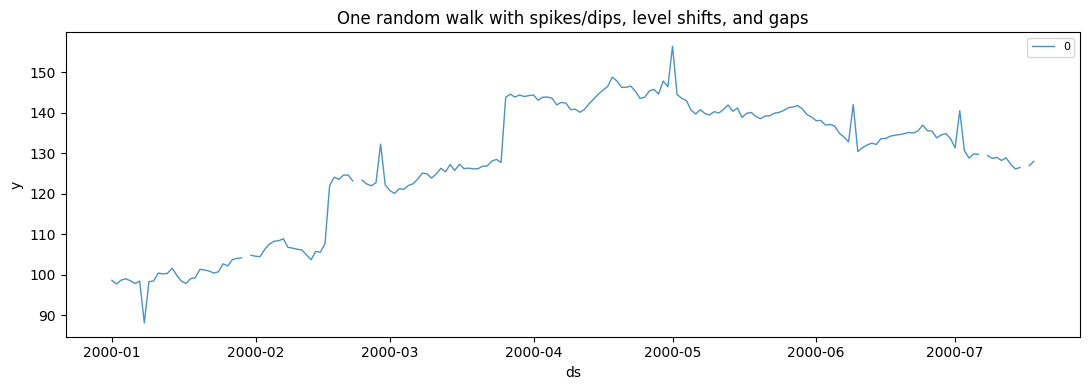

In [ ]:
messy = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    start_value=100.0,
    seed=42,
    # spikes and dips
    anomalies=True,
    anomaly_fraction=0.03,
    anomaly_types=["spike", "dip"],
    # abrupt level shifts
    changepoints=True,
    num_changepoints=2,
    changepoint_type="level",
    # gaps
    missing_data=True,
    missing_rate=0.02,
)
plot_panel(
    messy.generate(n_series=1),
    "One random walk with spikes/dips, level shifts, and gaps",
)

::: {.callout-note}
## Each pattern has its own guide

The knobs above are the quick version. Fine-grained control lives in the capability guides: [anomalies](/synforecast/docs/capabilities/anomalies.html), [changepoints](/synforecast/docs/capabilities/changepoints.html), and [missingness](/synforecast/docs/capabilities/missingness.html). To attach exogenous regressors, see [exogenous](/synforecast/docs/capabilities/exogenous.html).
:::

## 4. Combine generators into one dataset

A realistic panel mixes behaviors. `SynSet` composes several generators into a single long-format dataset, with each generator contributing a batch of series under its own ids.

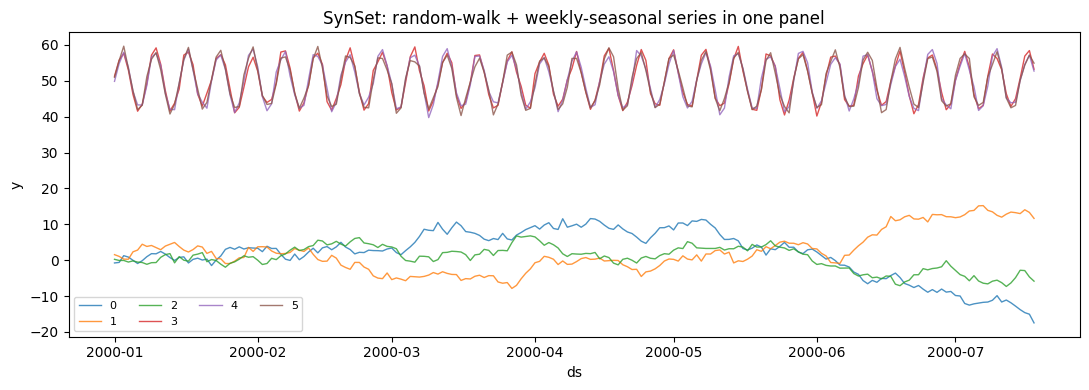

In [ ]:
from synforecast import SynSet
from synforecast.generators import SeasonalGenerator

dataset = SynSet(
    [
        RandomWalkGenerator(
            engine="polars", min_length=200, max_length=200, freq="D", seed=1
        ),
        SeasonalGenerator(
            engine="polars",
            min_length=200,
            max_length=200,
            freq="D",
            seasonality_period=7,
            seasonality_amplitude=8.0,
            seed=2,
        ),
    ]
)
mixed = dataset.generate(n_series_per_generator=3)
plot_panel(mixed, "SynSet: random-walk + weekly-seasonal series in one panel")

::: {.callout-warning}
## Reproducibility and the alpha API

Generation is fully seeded: the same inputs produce the same panel across runs and regardless of `n_jobs`. SynForecast is in alpha, so seed-identical outputs may change between releases — pin a version if you depend on exact values.
:::

## Where to go next

- **Generators** — 31 generator classes from SARIMA, ETS, and GARCH to Gaussian processes and the [KernelSynth](/synforecast/docs/generators/pretraining/kernel_synth.html) pretraining recipe. Start with [random walk](/synforecast/docs/generators/statistical/random_walk.html) or [seasonal](/synforecast/docs/generators/statistical/seasonal.html).
- **[Augmentation](/synforecast/docs/capabilities/augmentation.html)** — expand a small real panel with `SynAugment` or TSMixup.
- **[Balanced pool](/synforecast/docs/capabilities/balanced_pool.html)** — what `generate_series` draws from by default, and how to tailor it.
- **Integrations** — end-to-end workflows with [statsforecast](/synforecast/docs/integrations/statsforecast.html), [mlforecast](/synforecast/docs/integrations/mlforecast.html), and [neuralforecast](/synforecast/docs/integrations/neuralforecast.html).